In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("qmof.csv")

for col in df.columns:
    print(col)

#print(df['outputs.pbe.bandgap'].head)

qmof_id
name
info.formula
info.formula_reduced
info.mofid.mofid
info.mofid.mofkey
info.mofid.smiles_nodes
info.mofid.smiles_linkers
info.mofid.smiles
info.mofid.topology
info.natoms
info.pld
info.lcd
info.density
info.volume
info.symmetry.spacegroup
info.symmetry.spacegroup_number
info.symmetry.spacegroup_crystal
info.symmetry.pointgroup
info.synthesized
info.source
info.doi
inputs.pbe.theory
inputs.pbe.pseudopotentials
inputs.pbe.encut
inputs.pbe.kpoints
inputs.pbe.gamma
inputs.pbe.spin
outputs.pbe.energy_total
outputs.pbe.energy_vdw
outputs.pbe.energy_elec
outputs.pbe.net_magmom
outputs.pbe.bandgap
outputs.pbe.cbm
outputs.pbe.vbm
outputs.pbe.directgap
outputs.pbe.bandgap_spins
outputs.pbe.cbm_spins
outputs.pbe.vbm_spins
outputs.pbe.directgap_spins
inputs.hle17.theory
inputs.hle17.pseudopotentials
inputs.hle17.encut
inputs.hle17.kpoints
inputs.hle17.gamma
inputs.hle17.spin
inputs.hse06_10hf.theory
inputs.hse06_10hf.pseudopotentials
inputs.hse06_10hf.encut
inputs.hse06_10hf.kpoints
inp

C:\Users\mattb\AppData\Local\Temp\ipykernel_18860\187440021.py:1: DtypeWarning: Columns (0: inputs.hle17.theory, 1: inputs.hle17.pseudopotentials, 2: inputs.hle17.kpoints, 3: inputs.hle17.gamma, 4: inputs.hle17.spin, 5: inputs.hse06_10hf.theory, 6: inputs.hse06_10hf.pseudopotentials, 7: inputs.hse06_10hf.kpoints, 8: inputs.hse06_10hf.gamma, 9: inputs.hse06_10hf.spin, 10: inputs.hse06.theory, 11: inputs.hse06.pseudopotentials, 12: inputs.hse06.kpoints, 13: inputs.hse06.gamma, 14: inputs.hse06.spin, 15: outputs.hle17.directgap, 16: outputs.hle17.bandgap_spins, 17: outputs.hle17.cbm_spins, 18: outputs.hle17.vbm_spins, 19: outputs.hle17.directgap_spins, 20: outputs.hse06_10hf.directgap, 21: outputs.hse06_10hf.bandgap_spins, 22: outputs.hse06_10hf.cbm_spins, 23: outputs.hse06_10hf.vbm_spins, 24: outputs.hse06_10hf.directgap_spins, 25: outputs.hse06.directgap, 26: outputs.hse06.bandgap_spins, 27: outputs.hse06.cbm_spins, 28: outputs.hse06.vbm_spins, 29: outputs.hse06.directgap_spins) have mi

Featurs we are going to use to predict the band gap:


info.natoms,
info.pld,
info.lcd,
info.density,
info.volume,
info.symmetry.spacegroup,
info.symmetry.spacegroup_number,
info.symmetry.spacegroup_crystal,
info.symmetry.pointgroup


NOW WE HAVE TO CLEAN THE DATA AND CONVERT TEXTUAL DATA IN ONE-HOT VECTOR

In [3]:

df['energy_per_atom'] = df['outputs.pbe.energy_total'] / df['info.natoms']
df.head()


,qmof_id,name,info.formula,info.formula_reduced,info.mofid.mofid,info.mofid.mofkey,info.mofid.smiles_nodes,info.mofid.smiles_linkers,info.mofid.smiles,info.mofid.topology,...,outputs.hse06.net_magmom,outputs.hse06.bandgap,outputs.hse06.cbm,outputs.hse06.vbm,outputs.hse06.directgap,outputs.hse06.bandgap_spins,outputs.hse06.cbm_spins,outputs.hse06.vbm_spins,outputs.hse06.directgap_spins,energy_per_atom
0,qmof-8a95c27,ABACUF01_FSR,Ba2CuC6H14O16,Ba2CuC6H14O16,NaN,NaN,"['O', '[Ba]', '[Cu]']",['[O-]C=O'],O.[Ba].[Cu].[O-]C=O,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.119523
1,qmof-019ba28,ABALOF_FSR,Cu12C36H56I16N4S4,Cu3C9H14I4NS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.250365
2,qmof-830ed1c,ABAVIJ_FSR,Co4C48H32N8O16,CoC12H8N2O4,[Co].[O-]C(=O)c1ccncc1 MOFid-v1.rtl.cat0,Co.TWBYWOBDOCUKOW.MOFkey-v1.rtl,['[Co]'],['[O-]C(=O)c1ccncc1'],[Co].[O-]C(=O)c1ccncc1,rtl,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.037001
3,qmof-5bd4a24,ABAVOP_FSR,Co4C48H32N8O16,CoC12H8N2O4,[Co].[O-]C(=O)c1ccncc1 MOFid-v1.rtl.cat0,Co.TWBYWOBDOCUKOW.MOFkey-v1.rtl,['[Co]'],['[O-]C(=O)c1ccncc1'],[Co].[O-]C(=O)c1ccncc1,rtl,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.037994
4,qmof-644aab4,ABAXUZ_FSR,Zn2C50H32N6O8S4,ZnC25H16N3O4S2,NaN,NaN,['[Zn][Zn]'],"['[O-]C(=O)c1cccc(c1)c1nccs1', 'n1ccc(cc1)c1cc...",[O-]C(=O)c1cccc(c1)c1nccs1.[Zn][Zn].n1ccc(cc1)...,NaN,...,0.0,2.901747,2.246703,-0.655044,True,"[None, None]","[None, None]","[None, None]","[None, None]",-6.870762


In [4]:
#info.natoms, info.pld,info.lcd,info.density,info.volume this featurs are only numeric, we have to clean from NaN

print(df[[ 'info.pld', 'info.lcd', 'info.density', 'info.volume', 'outputs.pbe.bandgap','energy_per_atom','outputs.pbe.energy_vdw']].isna().sum())

df_pulito=df.dropna(subset=[ 'info.pld', 'info.lcd', 'info.density', 'info.volume', 'energy_per_atom', 'outputs.pbe.energy_vdw'])


info.pld                  0
info.lcd                  0
info.density              0
info.volume               0
outputs.pbe.bandgap       0
energy_per_atom           0
outputs.pbe.energy_vdw    0
dtype: int64


NOW, WE TRY TO UNDERSTEND THE CORRELATION BEETWIN THE BANDGAP AND THIS FEATURS

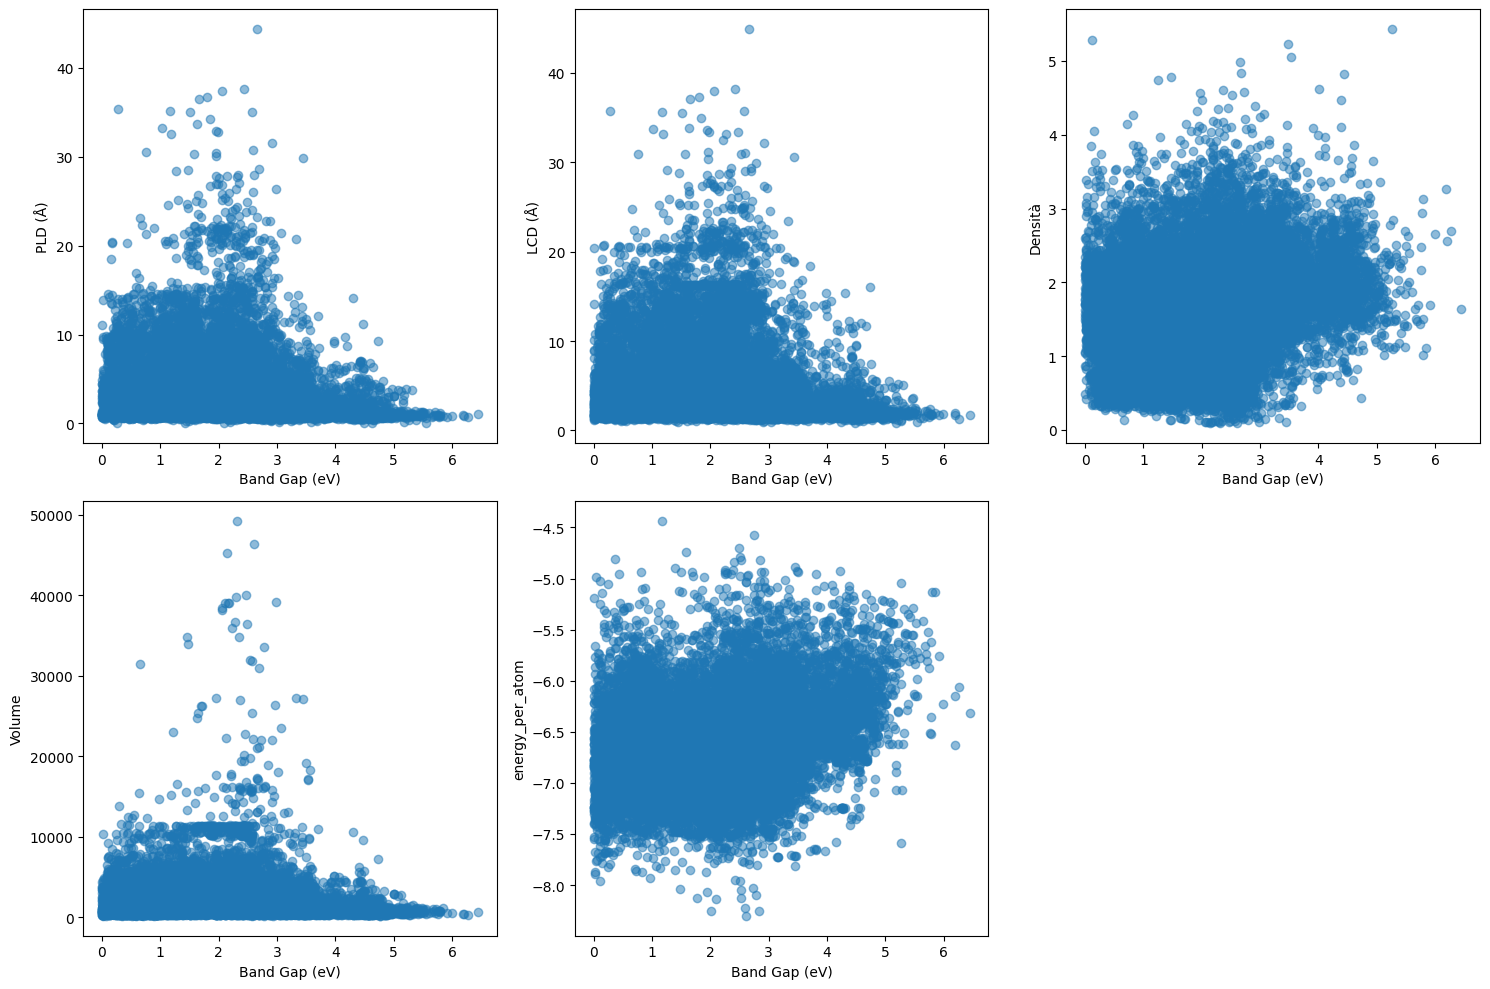

In [5]:

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
ax_list = axes.flatten()


features = ['info.pld', 'info.lcd', 'info.density', 'info.volume','energy_per_atom','outputs.pbe.energy_vdw']
labels = ['PLD (Å)', 'LCD (Å)', 'Densità', 'Volume','energy_per_atom','vdw_energy']

for i, feature in enumerate(features):
    ax_list[i].scatter(df_pulito['outputs.pbe.bandgap'], df_pulito[feature], alpha=0.5)
    ax_list[i].set_xlabel('Band Gap (eV)')
    ax_list[i].set_ylabel(labels[i])

ax_list[5].set_visible(False)

plt.tight_layout()
plt.show()

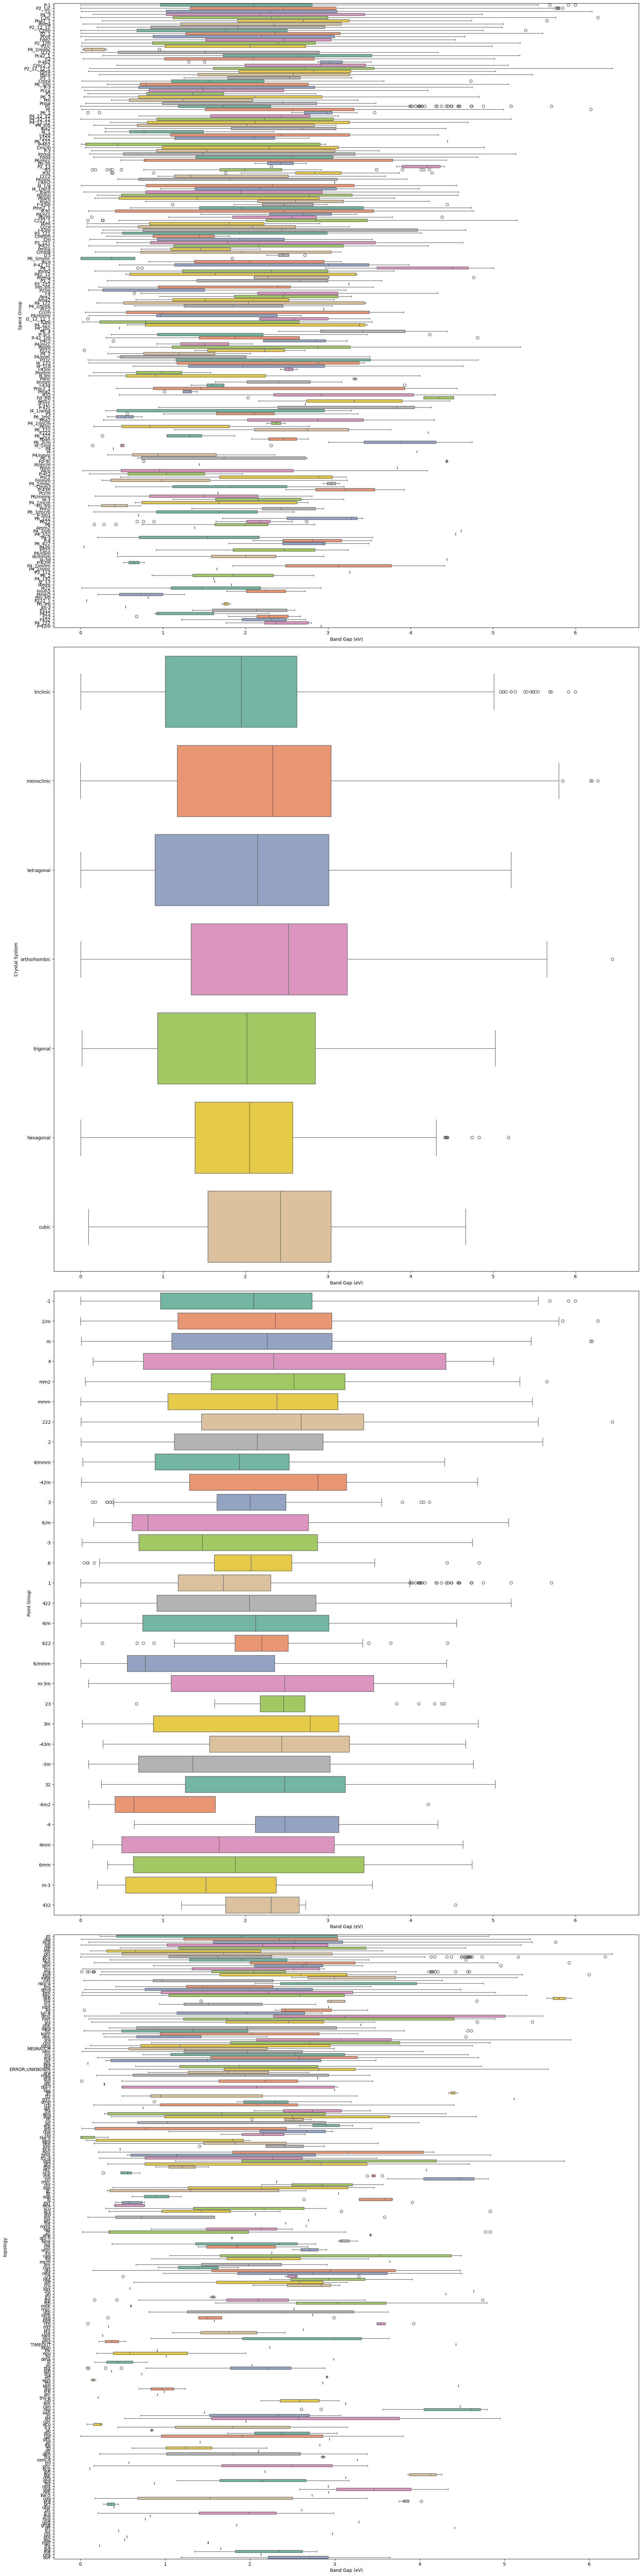

In [6]:

fig, axes = plt.subplots(4,1, figsize=(20, 80))

cat_cols = [
    'info.symmetry.spacegroup', 
    'info.symmetry.spacegroup_crystal', 
    'info.symmetry.pointgroup',
    'info.mofid.topology'
]

labels = [
    'Space Group', 
    'Crystal System', 
    'Point Group',
    'topology'
]

for i, feature in enumerate(cat_cols):
    sns.boxplot(ax=axes[i], x=df_pulito['outputs.pbe.bandgap'], y=df_pulito[feature], hue=df_pulito[feature], palette="Set2", legend=False)
    axes[i].set_xlabel('Band Gap (eV)')
    axes[i].set_ylabel(labels[i])

plt.tight_layout()
plt.show()


In [7]:

from pymatgen.core import Composition


composition_data = []

for formula in df['info.formula_reduced']:
    try:
       
        comp = Composition(formula)
        
        comp_dict = comp.as_dict()
        composition_data.append(comp_dict)
    except Exception as e:
        composition_data.append({})


df_elements = pd.DataFrame(composition_data)


df_elements = df_elements.fillna(0)

df_elements.head()

,Ba,Cu,C,H,O,I,N,S,Co,Zn,...,Np,Ru,Nb,W,Th,Tc,Be,Pu,Re,Hf
0,2.0,1.0,6.0,14.0,16.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,3.0,9.0,14.0,0.0,4.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,12.0,8.0,4.0,0.0,2.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,12.0,8.0,4.0,0.0,2.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,25.0,16.0,4.0,0.0,3.0,2.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


C:\Users\mattb\AppData\Local\Temp\ipykernel_18860\2915292263.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Elemento', y='Bandgap', data=df_plot, palette='Set3', fliersize=3)


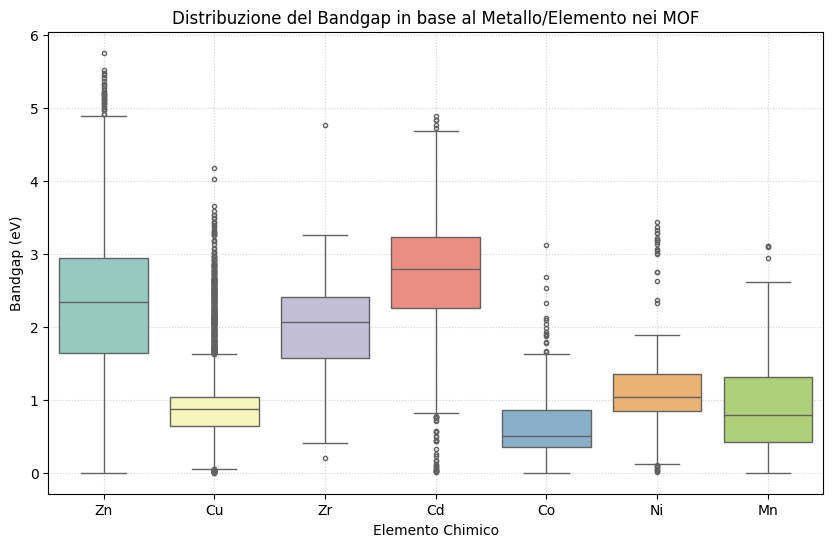

In [8]:

key_elements = ['Zn', 'Cu', 'Zr', 'Cd', 'Co', 'Ni', 'Mn']


existing_elements = [el for el in key_elements if el in df_elements.columns]


plot_data = []
for el in existing_elements:
    mask = df_elements[el] > 0
    sub_df = pd.DataFrame({
        'Elemento': el,
        'Bandgap': df.loc[mask, 'outputs.pbe.bandgap']
    })
    plot_data.append(sub_df)

if plot_data:
    df_plot = pd.concat(plot_data)

    # Creiamo il box plot
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Elemento', y='Bandgap', data=df_plot, palette='Set3', fliersize=3)
    
    plt.title("Distribuzione del Bandgap in base al Metallo/Elemento nei MOF")
    plt.xlabel("Elemento Chimico")
    plt.ylabel("Bandgap (eV)")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.show()

NOW WE HAVE TO TRANSFORM STR IN ONE-HOT VECTOR

In [ ]:
cat_cols = [
    'info.symmetry.spacegroup', 
    'info.symmetry.spacegroup_crystal', 
    'info.symmetry.pointgroup',
    'info.mofid.topology'
]

df_encoded = pd.get_dummies(df_pulito, columns=cat_cols, drop_first=True)

qmof_id
name
info.formula
info.formula_reduced
info.mofid.mofid
info.mofid.mofkey
info.mofid.smiles_nodes
info.mofid.smiles_linkers
info.mofid.smiles
info.natoms
info.pld
info.lcd
info.density
info.volume
info.symmetry.spacegroup_number
info.synthesized
info.source
info.doi
inputs.pbe.theory
inputs.pbe.pseudopotentials
inputs.pbe.encut
inputs.pbe.kpoints
inputs.pbe.gamma
inputs.pbe.spin
outputs.pbe.energy_total
outputs.pbe.energy_vdw
outputs.pbe.energy_elec
outputs.pbe.net_magmom
outputs.pbe.bandgap
outputs.pbe.cbm
outputs.pbe.vbm
outputs.pbe.directgap
outputs.pbe.bandgap_spins
outputs.pbe.cbm_spins
outputs.pbe.vbm_spins
outputs.pbe.directgap_spins
inputs.hle17.theory
inputs.hle17.pseudopotentials
inputs.hle17.encut
inputs.hle17.kpoints
inputs.hle17.gamma
inputs.hle17.spin
inputs.hse06_10hf.theory
inputs.hse06_10hf.pseudopotentials
inputs.hse06_10hf.encut
inputs.hse06_10hf.kpoints
inputs.hse06_10hf.gamma
inputs.hse06_10hf.spin
inputs.hse06.theory
inputs.hse06.pseudopotentials
inputs.hs

WE HAVE TO COMBINE THE TWO DATASET (df_elementi, df_encoded)

In [10]:
df_tot= pd.concat([df_encoded, df_elements], axis=1)

df_tot.head()
for col in df_tot.columns:
    print(col)

qmof_id
name
info.formula
info.formula_reduced
info.mofid.mofid
info.mofid.mofkey
info.mofid.smiles_nodes
info.mofid.smiles_linkers
info.mofid.smiles
info.natoms
info.pld
info.lcd
info.density
info.volume
info.symmetry.spacegroup_number
info.synthesized
info.source
info.doi
inputs.pbe.theory
inputs.pbe.pseudopotentials
inputs.pbe.encut
inputs.pbe.kpoints
inputs.pbe.gamma
inputs.pbe.spin
outputs.pbe.energy_total
outputs.pbe.energy_vdw
outputs.pbe.energy_elec
outputs.pbe.net_magmom
outputs.pbe.bandgap
outputs.pbe.cbm
outputs.pbe.vbm
outputs.pbe.directgap
outputs.pbe.bandgap_spins
outputs.pbe.cbm_spins
outputs.pbe.vbm_spins
outputs.pbe.directgap_spins
inputs.hle17.theory
inputs.hle17.pseudopotentials
inputs.hle17.encut
inputs.hle17.kpoints
inputs.hle17.gamma
inputs.hle17.spin
inputs.hse06_10hf.theory
inputs.hse06_10hf.pseudopotentials
inputs.hse06_10hf.encut
inputs.hse06_10hf.kpoints
inputs.hse06_10hf.gamma
inputs.hse06_10hf.spin
inputs.hse06.theory
inputs.hse06.pseudopotentials
inputs.hs

In [11]:
X=df_tot[['energy_per_atom', 'info.pld', 'info.lcd', 'info.density', 'info.volume','outputs.pbe.energy_vdw', 'info.symmetry.spacegroup_Aem2',
'info.symmetry.spacegroup_Ama2',
'info.symmetry.spacegroup_Amm2',
'info.symmetry.spacegroup_C2',
'info.symmetry.spacegroup_C2/c',
'info.symmetry.spacegroup_C2/m',
'info.symmetry.spacegroup_C222',
'info.symmetry.spacegroup_C222_1',
'info.symmetry.spacegroup_Cc',
'info.symmetry.spacegroup_Ccc2',
'info.symmetry.spacegroup_Ccce',
'info.symmetry.spacegroup_Cccm',
'info.symmetry.spacegroup_Cm',
'info.symmetry.spacegroup_Cmc2_1',
'info.symmetry.spacegroup_Cmce',
'info.symmetry.spacegroup_Cmcm',
'info.symmetry.spacegroup_Cmm2',
'info.symmetry.spacegroup_Cmme',
'info.symmetry.spacegroup_Cmmm',
'info.symmetry.spacegroup_F-43m',
'info.symmetry.spacegroup_F222',
'info.symmetry.spacegroup_F23',
'info.symmetry.spacegroup_F432',
'info.symmetry.spacegroup_Fd-3c',
'info.symmetry.spacegroup_Fd-3m',
'info.symmetry.spacegroup_Fdd2',
'info.symmetry.spacegroup_Fddd',
'info.symmetry.spacegroup_Fm-3m',
'info.symmetry.spacegroup_Fmm2',
'info.symmetry.spacegroup_Fmmm',
'info.symmetry.spacegroup_I-4',
'info.symmetry.spacegroup_I-42d',
'info.symmetry.spacegroup_I-42m',
'info.symmetry.spacegroup_I-43d',
'info.symmetry.spacegroup_I-43m',
'info.symmetry.spacegroup_I-4c2',
'info.symmetry.spacegroup_I-4m2',
'info.symmetry.spacegroup_I222',
'info.symmetry.spacegroup_I23',
'info.symmetry.spacegroup_I2_12_12_1',
'info.symmetry.spacegroup_I2_13',
'info.symmetry.spacegroup_I4',
'info.symmetry.spacegroup_I4/m',
'info.symmetry.spacegroup_I4/mcm',
'info.symmetry.spacegroup_I4/mmm',
'info.symmetry.spacegroup_I422',
'info.symmetry.spacegroup_I4_1',
'info.symmetry.spacegroup_I4_1/a',
'info.symmetry.spacegroup_I4_1/acd',
'info.symmetry.spacegroup_I4_1/amd',
'info.symmetry.spacegroup_I4_122',
'info.symmetry.spacegroup_I4_1cd',
'info.symmetry.spacegroup_I4_1md',
'info.symmetry.spacegroup_I4mm',
'info.symmetry.spacegroup_Ia-3',
'info.symmetry.spacegroup_Ia-3d',
'info.symmetry.spacegroup_Iba2',
'info.symmetry.spacegroup_Ibam',
'info.symmetry.spacegroup_Ibca',
'info.symmetry.spacegroup_Im-3',
'info.symmetry.spacegroup_Im-3m',
'info.symmetry.spacegroup_Ima2',
'info.symmetry.spacegroup_Imm2',
'info.symmetry.spacegroup_Imma',
'info.symmetry.spacegroup_Immm',
'info.symmetry.spacegroup_P-1',
'info.symmetry.spacegroup_P-3',
'info.symmetry.spacegroup_P-31c',
'info.symmetry.spacegroup_P-3c1',
'info.symmetry.spacegroup_P-3m1',
'info.symmetry.spacegroup_P-4',
'info.symmetry.spacegroup_P-42_1c',
'info.symmetry.spacegroup_P-42_1m',
'info.symmetry.spacegroup_P-42c',
'info.symmetry.spacegroup_P-42m',
'info.symmetry.spacegroup_P-43n',
'info.symmetry.spacegroup_P-4b2',
'info.symmetry.spacegroup_P-4c2',
'info.symmetry.spacegroup_P-4n2',
'info.symmetry.spacegroup_P-62c',
'info.symmetry.spacegroup_P-62m',
'info.symmetry.spacegroup_P1',
'info.symmetry.spacegroup_P2',
'info.symmetry.spacegroup_P2/c',
'info.symmetry.spacegroup_P2/m',
'info.symmetry.spacegroup_P222',
'info.symmetry.spacegroup_P222_1',
'info.symmetry.spacegroup_P2_1',
'info.symmetry.spacegroup_P2_1/c',
'info.symmetry.spacegroup_P2_1/m',
'info.symmetry.spacegroup_P2_12_12',
'info.symmetry.spacegroup_P2_12_12_1',
'info.symmetry.spacegroup_P2_13',
'info.symmetry.spacegroup_P3',
'info.symmetry.spacegroup_P312',
'info.symmetry.spacegroup_P31c',
'info.symmetry.spacegroup_P321',
'info.symmetry.spacegroup_P3_1',
'info.symmetry.spacegroup_P3_112',
'info.symmetry.spacegroup_P3_121',
'info.symmetry.spacegroup_P3_2',
'info.symmetry.spacegroup_P3_212',
'info.symmetry.spacegroup_P3_221',
'info.symmetry.spacegroup_P4',
'info.symmetry.spacegroup_P4/m',
'info.symmetry.spacegroup_P4/mcc',
'info.symmetry.spacegroup_P4/mmm',
'info.symmetry.spacegroup_P4/mnc',
'info.symmetry.spacegroup_P4/n',
'info.symmetry.spacegroup_P4/nbm',
'info.symmetry.spacegroup_P4/ncc',
'info.symmetry.spacegroup_P4/nmm',
'info.symmetry.spacegroup_P4/nnc',
'info.symmetry.spacegroup_P422',
'info.symmetry.spacegroup_P42_12',
'info.symmetry.spacegroup_P4_1',
'info.symmetry.spacegroup_P4_122',
'info.symmetry.spacegroup_P4_12_12',
'info.symmetry.spacegroup_P4_132',
'info.symmetry.spacegroup_P4_2',
'info.symmetry.spacegroup_P4_2/mbc',
'info.symmetry.spacegroup_P4_2/mcm',
'info.symmetry.spacegroup_P4_2/mmc',
'info.symmetry.spacegroup_P4_2/mnm',
'info.symmetry.spacegroup_P4_2/n',
'info.symmetry.spacegroup_P4_2/ncm',
'info.symmetry.spacegroup_P4_2/nmc',
'info.symmetry.spacegroup_P4_2/nnm',
'info.symmetry.spacegroup_P4_222',
'info.symmetry.spacegroup_P4_22_12',
'info.symmetry.spacegroup_P4_2bc',
'info.symmetry.spacegroup_P4_2nm',
'info.symmetry.spacegroup_P4_3',
'info.symmetry.spacegroup_P4_322',
'info.symmetry.spacegroup_P4_32_12',
'info.symmetry.spacegroup_P4_332',
'info.symmetry.spacegroup_P4nc',
'info.symmetry.spacegroup_P6',
'info.symmetry.spacegroup_P6/m',
'info.symmetry.spacegroup_P6/mcc',
'info.symmetry.spacegroup_P6/mmm',
'info.symmetry.spacegroup_P622',
'info.symmetry.spacegroup_P6_1',
'info.symmetry.spacegroup_P6_122',
'info.symmetry.spacegroup_P6_2',
'info.symmetry.spacegroup_P6_222',
'info.symmetry.spacegroup_P6_3',
'info.symmetry.spacegroup_P6_3/m',
'info.symmetry.spacegroup_P6_3/mcm',
'info.symmetry.spacegroup_P6_3/mmc',
'info.symmetry.spacegroup_P6_322',
'info.symmetry.spacegroup_P6_3cm',
'info.symmetry.spacegroup_P6_3mc',
'info.symmetry.spacegroup_P6_4',
'info.symmetry.spacegroup_P6_422',
'info.symmetry.spacegroup_P6_5',
'info.symmetry.spacegroup_P6_522',
'info.symmetry.spacegroup_Pa-3',
'info.symmetry.spacegroup_Pba2',
'info.symmetry.spacegroup_Pbam',
'info.symmetry.spacegroup_Pban',
'info.symmetry.spacegroup_Pbca',
'info.symmetry.spacegroup_Pbcm',
'info.symmetry.spacegroup_Pbcn',
'info.symmetry.spacegroup_Pc',
'info.symmetry.spacegroup_Pca2_1',
'info.symmetry.spacegroup_Pcc2',
'info.symmetry.spacegroup_Pcca',
'info.symmetry.spacegroup_Pccm',
'info.symmetry.spacegroup_Pccn',
'info.symmetry.spacegroup_Pm',
'info.symmetry.spacegroup_Pm-3m',
'info.symmetry.spacegroup_Pma2',
'info.symmetry.spacegroup_Pmc2_1',
'info.symmetry.spacegroup_Pmm2',
'info.symmetry.spacegroup_Pmma',
'info.symmetry.spacegroup_Pmmm',
'info.symmetry.spacegroup_Pmmn',
'info.symmetry.spacegroup_Pmn2_1',
'info.symmetry.spacegroup_Pmna',
'info.symmetry.spacegroup_Pn-3m',
'info.symmetry.spacegroup_Pn-3n',
'info.symmetry.spacegroup_Pna2_1',
'info.symmetry.spacegroup_Pnc2',
'info.symmetry.spacegroup_Pnma',
'info.symmetry.spacegroup_Pnn2',
'info.symmetry.spacegroup_Pnna',
'info.symmetry.spacegroup_Pnnm',
'info.symmetry.spacegroup_Pnnn',
'info.symmetry.spacegroup_R-3',
'info.symmetry.spacegroup_R-3c',
'info.symmetry.spacegroup_R-3m',
'info.symmetry.spacegroup_R3',
'info.symmetry.spacegroup_R32',
'info.symmetry.spacegroup_R3c',
'info.symmetry.spacegroup_R3m',
'info.symmetry.spacegroup_crystal_hexagonal',
'info.symmetry.spacegroup_crystal_monoclinic',
'info.symmetry.spacegroup_crystal_orthorhombic',
'info.symmetry.spacegroup_crystal_tetragonal',
'info.symmetry.spacegroup_crystal_triclinic',
'info.symmetry.spacegroup_crystal_trigonal',
'info.symmetry.pointgroup_-3',
'info.symmetry.pointgroup_-3m',
'info.symmetry.pointgroup_-4',
'info.symmetry.pointgroup_-42m',
'info.symmetry.pointgroup_-43m',
'info.symmetry.pointgroup_-6m2',
'info.symmetry.pointgroup_1',
'info.symmetry.pointgroup_2',
'info.symmetry.pointgroup_2/m',
'info.symmetry.pointgroup_222',
'info.symmetry.pointgroup_23',
'info.symmetry.pointgroup_3',
'info.symmetry.pointgroup_32',
'info.symmetry.pointgroup_3m',
'info.symmetry.pointgroup_4',
'info.symmetry.pointgroup_4/m',
'info.symmetry.pointgroup_4/mmm',
'info.symmetry.pointgroup_422',
'info.symmetry.pointgroup_432',
'info.symmetry.pointgroup_4mm',
'info.symmetry.pointgroup_6',
'info.symmetry.pointgroup_6/m',
'info.symmetry.pointgroup_6/mmm',
'info.symmetry.pointgroup_622',
'info.symmetry.pointgroup_6mm',
'info.symmetry.pointgroup_m',
'info.symmetry.pointgroup_m-3',
'info.symmetry.pointgroup_m-3m',
'info.symmetry.pointgroup_mm2',
'info.symmetry.pointgroup_mmm',
'info.mofid.topology_MISMATCH',
'info.mofid.topology_TIMEOUT',
'info.mofid.topology_acs',
'info.mofid.topology_afi',
'info.mofid.topology_afw',
'info.mofid.topology_ant',
'info.mofid.topology_apo',
'info.mofid.topology_asc',
'info.mofid.topology_bbf',
'info.mofid.topology_bcg',
'info.mofid.topology_bct',
'info.mofid.topology_bcu',
'info.mofid.topology_bew',
'info.mofid.topology_bex',
'info.mofid.topology_bey',
'info.mofid.topology_bnn',
'info.mofid.topology_bor',
'info.mofid.topology_bpq',
'info.mofid.topology_cag',
'info.mofid.topology_can',
'info.mofid.topology_cdl',
'info.mofid.topology_cdq',
'info.mofid.topology_cds',
'info.mofid.topology_cdt',
'info.mofid.topology_ceg',
'info.mofid.topology_cem',
'info.mofid.topology_cem-d',
'info.mofid.topology_cor',
'info.mofid.topology_cpa',
'info.mofid.topology_cpc',
'info.mofid.topology_cpf',
'info.mofid.topology_cpi',
'info.mofid.topology_cpo',
'info.mofid.topology_cpr',
'info.mofid.topology_cpv',
'info.mofid.topology_cqx',
'info.mofid.topology_crb',
'info.mofid.topology_crs',
'info.mofid.topology_cru',
'info.mofid.topology_css',
'info.mofid.topology_ctn',
'info.mofid.topology_ddi',
'info.mofid.topology_deh',
'info.mofid.topology_dft',
'info.mofid.topology_dia',
'info.mofid.topology_dia-f',
'info.mofid.topology_dma',
'info.mofid.topology_dmc',
'info.mofid.topology_dmd',
'info.mofid.topology_dmp',
'info.mofid.topology_ecu',
'info.mofid.topology_eea',
'info.mofid.topology_eta',
'info.mofid.topology_etb',
'info.mofid.topology_etc',
'info.mofid.topology_etd',
'info.mofid.topology_etf',
'info.mofid.topology_fcu',
'info.mofid.topology_fes',
'info.mofid.topology_fet',
'info.mofid.topology_fff',
'info.mofid.topology_flt',
'info.mofid.topology_flu',
'info.mofid.topology_fon',
'info.mofid.topology_frl',
'info.mofid.topology_fsc',
'info.mofid.topology_fse',
'info.mofid.topology_fsg',
'info.mofid.topology_fsh',
'info.mofid.topology_fsx',
'info.mofid.topology_ftb',
'info.mofid.topology_ftw',
'info.mofid.topology_ggl',
'info.mofid.topology_gis',
'info.mofid.topology_gme',
'info.mofid.topology_gra',
'info.mofid.topology_gwg',
'info.mofid.topology_hbt',
'info.mofid.topology_hcb',
'info.mofid.topology_hex',
'info.mofid.topology_hms',
'info.mofid.topology_htb',
'info.mofid.topology_hwx',
'info.mofid.topology_hxg',
'info.mofid.topology_hxl',
'info.mofid.topology_ilc',
'info.mofid.topology_ins',
'info.mofid.topology_irl',
'info.mofid.topology_itv',
'info.mofid.topology_jaj',
'info.mofid.topology_jeb',
'info.mofid.topology_jph',
'info.mofid.topology_jsm',
'info.mofid.topology_jxj',
'info.mofid.topology_kdd',
'info.mofid.topology_ken',
'info.mofid.topology_kgd',
'info.mofid.topology_kgm',
'info.mofid.topology_kkm',
'info.mofid.topology_lcs',
'info.mofid.topology_lcy',
'info.mofid.topology_lig',
'info.mofid.topology_lil',
'info.mofid.topology_lim',
'info.mofid.topology_llj',
'info.mofid.topology_llw-z',
'info.mofid.topology_lon',
'info.mofid.topology_lsz',
'info.mofid.topology_lvt',
'info.mofid.topology_lvt-a',
'info.mofid.topology_mab',
'info.mofid.topology_mcm',
'info.mofid.topology_mdf',
'info.mofid.topology_met',
'info.mofid.topology_mmt',
'info.mofid.topology_moc',
'info.mofid.topology_mog',
'info.mofid.topology_mok',
'info.mofid.topology_mot',
'info.mofid.topology_mrc',
'info.mofid.topology_mtf',
'info.mofid.topology_myc',
'info.mofid.topology_nbo',
'info.mofid.topology_nbo-a',
'info.mofid.topology_ncb',
'info.mofid.topology_neb',
'info.mofid.topology_nia',
'info.mofid.topology_nia-d',
'info.mofid.topology_nkc',
'info.mofid.topology_nod',
'info.mofid.topology_nog',
'info.mofid.topology_nou',
'info.mofid.topology_nov',
'info.mofid.topology_noy',
'info.mofid.topology_oft',
'info.mofid.topology_pcb',
'info.mofid.topology_pcu',
'info.mofid.topology_pth',
'info.mofid.topology_pto',
'info.mofid.topology_pts',
'info.mofid.topology_pyr',
'info.mofid.topology_qtz',
'info.mofid.topology_qtz-h',
'info.mofid.topology_qzd',
'info.mofid.topology_raa',
'info.mofid.topology_rna',
'info.mofid.topology_rnb',
'info.mofid.topology_rob',
'info.mofid.topology_rtl',
'info.mofid.topology_scu',
'info.mofid.topology_sdb',
'info.mofid.topology_sdd',
'info.mofid.topology_sdf',
'info.mofid.topology_sit',
'info.mofid.topology_skb',
'info.mofid.topology_sne',
'info.mofid.topology_sod',
'info.mofid.topology_sql',
'info.mofid.topology_sqp',
'info.mofid.topology_sra',
'info.mofid.topology_srs',
'info.mofid.topology_ssb',
'info.mofid.topology_std',
'info.mofid.topology_stp',
'info.mofid.topology_sty',
'info.mofid.topology_sur',
'info.mofid.topology_sxb',
'info.mofid.topology_tav',
'info.mofid.topology_tbo',
'info.mofid.topology_tcb',
'info.mofid.topology_tcs',
'info.mofid.topology_tfa',
'info.mofid.topology_tfg',
'info.mofid.topology_tfi',
'info.mofid.topology_tfj',
'info.mofid.topology_tfk',
'info.mofid.topology_tfo',
'info.mofid.topology_tfz',
'info.mofid.topology_tfz-d',
'info.mofid.topology_the',
'info.mofid.topology_thl',
'info.mofid.topology_ths',
'info.mofid.topology_ths-e',
'info.mofid.topology_tsa',
'info.mofid.topology_tsg',
'info.mofid.topology_tsi',
'info.mofid.topology_tsy',
'info.mofid.topology_ttp',
'info.mofid.topology_twt',
'info.mofid.topology_ubo',
'info.mofid.topology_umc',
'info.mofid.topology_unc',
'info.mofid.topology_uni',
'info.mofid.topology_uog',
'info.mofid.topology_usf',
'info.mofid.topology_utj',
'info.mofid.topology_utk',
'info.mofid.topology_utp',
'info.mofid.topology_vbk',
'info.mofid.topology_wix',
'info.mofid.topology_wys',
'info.mofid.topology_xah',
'info.mofid.topology_xat',
'info.mofid.topology_xmz',
'info.mofid.topology_xww',
'info.mofid.topology_yav',
'info.mofid.topology_zni',
'info.mofid.topology_zst',
'info.mofid.topology_zxc',
'info.mofid.topology_zyl',
'Ba',
'Cu',
'C',
'H',
'O',
'I',
'N',
'S',
'Co',
'Zn',
'Ag',
'Pb',
'Dy',
'La',
'Pr',
'Nd',
'Cl',
'Sm',
'Eu',
'Gd',
'Mn',
'Cd',
'In',
'Hg',
'Na',
'Br',
'Pd',
'K',
'Fe',
'F',
'Rb',
'Cs',
'Ca',
'Ni',
'Y',
'Tb',
'Mg',
'Er',
'Ce',
'Sn',
'P',
'Li',
'Ga',
'Mo',
'Se',
'V',
'Ho',
'Yb',
'Bi',
'Sr',
'Au',
'Tl',
'B',
'Ir',
'Rh',
'U',
'Ti',
'Lu',
'Sb',
'Si',
'Sc',
'Ge',
'Pt',
'Al',
'Cr',
'Zr',
'Te',
'Tm',
'As',
'Np',
'Ru',
'Nb',
'W',
'Th',
'Tc',
'Be',
'Pu',
'Re',
'Hf'
]]
y=df_tot['outputs.pbe.bandgap']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

TRAIN THE MODELS

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
lr_model=LinearRegression()

lr_model.fit(X_train,y_train)

y_pred_lr=lr_model.predict(X_test)

def evaluate_model(y_true, y_pred, name="Model"):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"--- {name} ---")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}\n")

evaluate_model(y_test, y_pred_lr, "Linear Regression")


--- Linear Regression ---
R² Score: 0.5156
RMSE: 0.7945



In [15]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

evaluate_model(y_test, y_pred_ridge, "Ridge Regression")

--- Ridge Regression ---
R² Score: 0.5221
RMSE: 0.7891



In [16]:
rf_model=RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train,y_train)

y_pred_rf=rf_model.predict(X_test)

evaluate_model(y_test, y_pred_rf, "RandomForestRegressor")

--- RandomForestRegressor ---
R² Score: 0.7274
RMSE: 0.5960



In [17]:
mlp_model = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation='relu',            
        solver='adam',                
        max_iter=500,                 
        random_state=42
    )
)


mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)

evaluate_model(y_test, y_pred_mlp, "MLPRegressor")

--- MLPRegressor ---
R² Score: 0.6149
RMSE: 0.7083



c:\Users\mattb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


In [18]:
svr_model = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=15.0, epsilon=0.01)
)


svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_test)

evaluate_model(y_test, y_pred_svr, "MLPRegressor")

--- MLPRegressor ---
R² Score: 0.5752
RMSE: 0.7440

